In [91]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

In [92]:

# Note: Download the datasets from Kaggle and place them in the week4 folder
# Salary dataset: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression
# Social Network Ads: https://www.kaggle.com/datasets/rakeshrau/social-network-ads


# Load Salary dataset for Linear Regression
salary_df = pd.read_csv('Salary_dataset.csv')
print("Salary dataset loaded successfully!")
print(f"Shape: {salary_df.shape}")
print(salary_df.head())


# Load Social Network Ads dataset for Logistic Regression
ads_df = pd.read_csv('Social_Network_Ads.csv')
print("\nSocial Network Ads dataset loaded successfully!")
print(f"Shape: {ads_df.shape}")
print(ads_df.head())

Salary dataset loaded successfully!
Shape: (30, 3)
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0

Social Network Ads dataset loaded successfully!
Shape: (400, 5)
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [93]:

# Data preprocessing
# For salary data
X_salary = salary_df.drop(['Salary', 'Unnamed: 0'], axis=1)
y_salary = salary_df['Salary'].values

# For ads data
X_ads = ads_df[['Age', 'EstimatedSalary']].values
y_ads = ads_df['Purchased'].values

# Split datasets
X_salary_train, X_salary_test, y_salary_train, y_salary_test = train_test_split(
    X_salary, y_salary, test_size=0.2, random_state=42)

X_ads_train, X_ads_test, y_ads_train, y_ads_test = train_test_split(
    X_ads, y_ads, test_size=0.2, random_state=42)

print(f"\nSalary dataset split: Train {X_salary_train.shape}, Test {X_salary_test.shape}")
print(f"Ads dataset split: Train {X_ads_train.shape}, Test {X_ads_test.shape}")


Salary dataset split: Train (24, 1), Test (6, 1)
Ads dataset split: Train (320, 2), Test (80, 2)


## 1. Linear Regression

Linear regression is a fundamental supervised learning algorithm used for predicting continuous values. It assumes a linear relationship between input features and the target variable.

### Mathematical Foundation

**Hypothesis Function:**
$$h_\beta(x) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

**Cost Function (Mean Squared Error):**
$$J(\beta) = \frac{1}{2m} \sum_{i=1}^m (h_\beta(x_{i}) - y_{i})^2$$

**Gradient Descent Update:**
$$\beta_j := \beta_j - \alpha \frac{\partial}{\partial \beta_j} J(\beta)$$

**Partial Derivative:**
$$\frac{\partial}{\partial \beta_j} J(\beta) = \frac{1}{m} \sum_{i=1}^m (h_\beta(x_{i}) - y_{i})$$

Where:
- $m$ = number of training examples
- $n$ = number of features
- $\alpha$ = learning rate
- $\beta$ = parameters (weights)

![Logistic Regression Pipeline](linear_regression_pipeline.svg)

*Figure: Complete linear regression model steps*

In [94]:
# Step 2: add x0 =1 to dataset
X_train_0 = np.c_[np.ones((X_salary_train.shape[0],1)),X_salary_train]
X_test_0 = np.c_[np.ones((X_salary_test.shape[0],1)),X_salary_test]

print("\nFirst 5 rows of X_train_0:")
print(X_train_0[:5])


First 5 rows of X_train_0:
[[ 1.  10.4]
 [ 1.   8.8]
 [ 1.   4.1]
 [ 1.   1.2]
 [ 1.   2.3]]


In [95]:
# Step3: build model
beta = np.matmul(np.linalg.inv( np.matmul(X_train_0.T,X_train_0) ), np.matmul(X_train_0.T,y_salary_train))

In [96]:
# The parameters for linear regression model
parameter = ['beta_'+str(i) for i in range(X_train_0.shape[1])]
columns = ['intersect:x_0=1'] + list(X_salary.columns.values)
parameter_df = pd.DataFrame({'Parameter':parameter,'Columns':columns,'beta':beta})

In [97]:
print(parameter_df)

  Parameter          Columns          beta
0    beta_0  intersect:x_0=1  24380.201479
1    beta_1  YearsExperience   9423.815323


In [98]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_salary_train,y_salary_train) # Note: x_0 =1 is no need to add, sklearn will take care of it.

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [99]:
#Parameter
sk_beta = [lin_reg.intercept_]+list(lin_reg.coef_)
parameter_df = parameter_df.join(pd.Series(sk_beta, name='Sklearn_beta'))
parameter_df

,Parameter,Columns,beta,Sklearn_beta
0,beta_0,intersect:x_0=1,24380.201479,24380.201479
1,beta_1,YearsExperience,9423.815323,9423.815323


In [100]:
# Step 4: Prediction 
# Using Normal equation (without gradient descent)
y_pred_norm =  np.matmul(X_test_0,beta)

# Step 5: Evaluation
# Evaluation: Mean Squared Error (MSE)
J_mse = np.sum((y_pred_norm - y_salary_test)**2)/ X_test_0.shape[0]

# R_square
sse = np.sum((y_pred_norm - y_salary_test)**2)
sst = np.sum((y_salary_test - y_salary_test.mean())**2)
R_square = 1 - (sse/sst)
print('The Mean Square Error(MSE) or J(beta) is: ',J_mse)
print('R square obtain for normal equation method is :',R_square)

The Mean Square Error(MSE) or J(beta) is:  49830096.85590804
R square obtain for normal equation method is : 0.9024461774180503


In [101]:
# sklearn regression module
y_pred_sk = lin_reg.predict(X_salary_test)

#Evaluvation: MSE
from sklearn.metrics import mean_squared_error
J_mse_sk = mean_squared_error(y_pred_sk, y_salary_test)

# R_square
R_square_sk = lin_reg.score(X_salary_test,y_salary_test)
print('The Mean Square Error(MSE) or J(beta) is: ',J_mse_sk)
print('R square obtain for scikit learn library is :',R_square_sk)

The Mean Square Error(MSE) or J(beta) is:  49830096.85590837
R square obtain for scikit learn library is : 0.9024461774180498


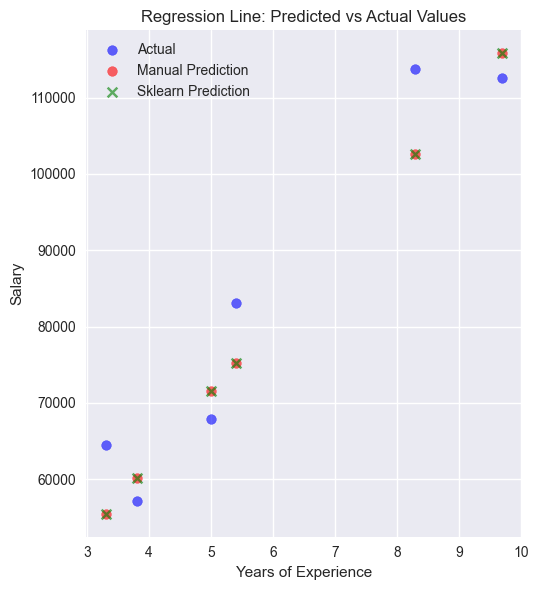

In [102]:
plt.subplot(1, 2, 2)
plt.scatter(X_salary_test, y_salary_test, color='blue', label='Actual', alpha=0.6)
plt.scatter(X_salary_test, y_pred_norm, color='red', label='Manual Prediction', alpha=0.6)
plt.scatter(X_salary_test, y_pred_sk, color='green', label='Sklearn Prediction', alpha=0.6, marker='x')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Regression Line: Predicted vs Actual Values')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [103]:
# Full implementation of Linear Regression with gradient descent and normal equation

class OurLinearRegression:
    def __init__(self, lr=0.01, n_iters=100):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit_gradient(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            y_hat = X @ self.w + self.b          # Step 3: no sigmoid

            # Step 5: MSE gradients
            dw = (2 / n_samples) * X.T @ (y_hat - y)
            db = (2 / n_samples) * np.sum(y_hat - y)

            # Step 6: update
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return X @ self.w + self.b               # Step 7: raw output

    def mse(self, X, y):
        return np.mean((self.predict(X) - y) ** 2)

    def r2(self, X, y):
        ss_res = np.sum((self.predict(X) - y) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot

    # Optional: closed-form solution (skip gradient descent entirely)
    def fit_normal_equation(self, X, y):
        X_b = np.c_[np.ones(X.shape[0]), X]     # prepend bias column
        beta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
        self.b, self.w = beta[0], beta[1:]

In [104]:
lr = OurLinearRegression(lr=0.01, n_iters=100)
lr.fit_gradient(X_salary_train, y_salary_train)
y_pred_custom = lr.predict(X_salary_test)
print("Custom Linear Regression MSE:", lr.mse(X_salary_test, y_salary_test))
print("Custom Linear Regression R^2:", lr.r2(X_salary_test, y_salary_test))

print("\nSklearn Linear Regression MSE:", J_mse_sk)
print("Sklearn Linear Regression R^2:", R_square_sk)

Custom Linear Regression MSE: 91147093.0834446
Custom Linear Regression R^2: 0.8215586982856012

Sklearn Linear Regression MSE: 49830096.85590837
Sklearn Linear Regression R^2: 0.9024461774180498


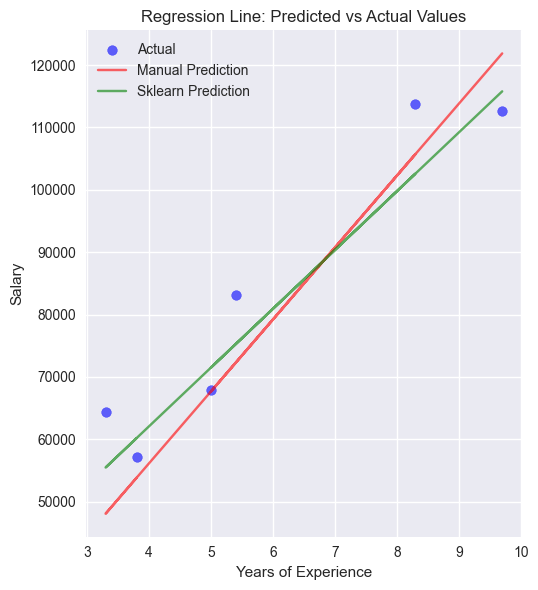

In [105]:
plt.subplot(1, 2, 2)
plt.scatter(X_salary_test, y_salary_test, color='blue', label='Actual', alpha=0.6)
plt.plot(X_salary_test, y_pred_custom, color='red', label='Manual Prediction', alpha=0.6)
plt.plot(X_salary_test, y_pred_sk, color='green', label='Sklearn Prediction', alpha=0.6, marker='x')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Regression Line: Predicted vs Actual Values')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 2. Logistic Regression

Logistic regression is used for binary classification problems. Unlike linear regression, logistic regression doesn't have a closed-form solution and requires optimization to find the best parameters.

### Mathematical Foundation

**Sigmoid Function:**
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Hypothesis Function:**
$$h_\beta(x) = P(y=1|x;\beta) = \sigma(\beta^T x) = \frac{1}{1 + e^{-\beta^T x}}$$

**Log-Likelihood Function:**
$$l(\beta) = \sum_{i=1}^m [y_{i} \log(h_\beta(x_{i})) + (1 - y_{i}) \log(1 - h_\beta(x_{i}))]$$

**Cost Function (Negative Log-Likelihood):**
$$J(\beta) = -\frac{1}{m} l(\beta) = -\frac{1}{m} \sum_{i=1}^m [y_{i} \log(h_\beta(x_{i})) + (1 - y_{i}) \log(1 - h_\beta(x_{i}))]$$

**Maximum Likelihood Estimation:**
We want to find $\beta$ that maximizes $l(\beta)$, which is equivalent to minimizing $J(\beta)$.

**Decision Rule:**
- Predict class 1 if $h_\beta(x) \geq 0.5$
- Predict class 0 if $h_\beta(x) < 0.5$

![Logistic Regression Pipeline](logistic_regression_pipeline.svg)

*Figure: Complete logistic regression model building steps*

Sigmoid function test:
sigmoid(-2) = 0.1192
sigmoid(-1) = 0.2689
sigmoid(0) = 0.5000
sigmoid(1) = 0.7311
sigmoid(2) = 0.8808


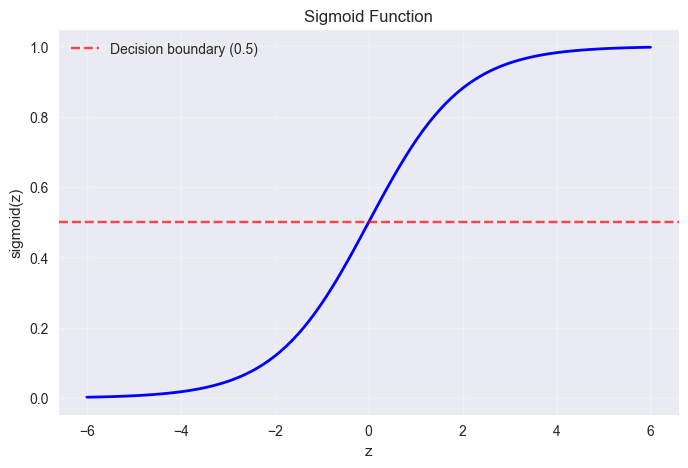

In [106]:
# Step 1: Define the sigmoid function
def sigmoid(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-z))

# Test the sigmoid function
z_test = np.array([-2, -1, 0, 1, 2])
print("Sigmoid function test:")
for z in z_test:
    print(f"sigmoid({z}) = {sigmoid(z):.4f}")

# Plot sigmoid function
z_plot = np.linspace(-6, 6, 100)
plt.figure(figsize=(8, 5))
plt.plot(z_plot, sigmoid(z_plot), 'b-', linewidth=2)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Function')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Decision boundary (0.5)')
plt.legend()
plt.show()

In [107]:
# Step 2: Initialize parameters and add bias term (x0 = 1)

# Scale the features first (important for gradient descent convergence)
scaler_log = StandardScaler()
X_ads_train_scaled_manual = scaler_log.fit_transform(X_ads_train)
X_ads_test_scaled_manual = scaler_log.transform(X_ads_test)

# Add bias term (x0 = 1)
X_train_log = np.c_[np.ones((X_ads_train_scaled_manual.shape[0], 1)), X_ads_train_scaled_manual]
X_test_log = np.c_[np.ones((X_ads_test_scaled_manual.shape[0], 1)), X_ads_test_scaled_manual]

# Initialize parameters (beta) to zeros
beta_log = np.zeros(X_train_log.shape[1])
print(f"\nInitial beta: {beta_log}")


Initial beta: [0. 0. 0.]


In [108]:
# Step 3: Implement cost function and gradient descent
# Adding cost function has shown to improve the accuracy

def compute_cost(X, y, beta):
    """Compute logistic regression cost function"""
    m = len(y)
    h = sigmoid(np.dot(X, beta))
    cost = (-1/m) * np.sum(y * np.log(h + 1e-15) + (1 - y) * np.log(1 - h + 1e-15))
    return cost

def gradient_descent_logistic(X, y, beta, learning_rate, n_iterations):
    """Perform gradient descent for logistic regression"""
    m = len(y)
    cost_history = []

    for i in range(n_iterations):
        h = sigmoid(np.dot(X, beta))
        gradient = (1/m) * np.dot(X.T, (h - y))
        beta = beta - learning_rate * gradient

        if i % 10 == 0:
            cost = compute_cost(X, y, beta)
            cost_history.append(cost)
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return beta, cost_history


In [109]:
# Step 4: Train the logistic regression model using gradient descent
learning_rate_log = 0.1
n_iterations_log = 100

print(f"Training with learning rate = {learning_rate_log}")
beta_final, cost_history_log = gradient_descent_logistic(
    X_train_log, y_ads_train, beta_log, learning_rate_log, n_iterations_log
)

print(f"\nFinal beta: {beta_final}")
print(f"Final cost: {cost_history_log[-1]:.6f}")

Training with learning rate = 0.1
Iteration 0: Cost = 0.680144
Iteration 10: Cost = 0.583071
Iteration 20: Cost = 0.525343
Iteration 30: Cost = 0.488674
Iteration 40: Cost = 0.463894
Iteration 50: Cost = 0.446286
Iteration 60: Cost = 0.433271
Iteration 70: Cost = 0.423346
Iteration 80: Cost = 0.415585
Iteration 90: Cost = 0.409392

Final beta: [-0.61654597  1.19024211  0.71380297]
Final cost: 0.409392


In [110]:
# Step 5: Make predictions and evaluate

def predict_logistic(X, beta, threshold=0.5):
    """Make predictions using logistic regression"""
    probabilities = sigmoid(np.dot(X, beta))
    return (probabilities >= threshold).astype(int), probabilities

# Make predictions
y_pred_manual, y_prob_manual = predict_logistic(X_test_log, beta_final)

# Compare with scikit-learn
from sklearn.linear_model import LogisticRegression
logr_sklearn_manual = LogisticRegression()
logr_sklearn_manual.fit(X_ads_train_scaled_manual, y_ads_train)
y_pred_sklearn_manual = logr_sklearn_manual.predict(X_ads_test_scaled_manual)

print("Manual Implementation Results:")
print(f"Accuracy: {accuracy_score(y_ads_test, y_pred_manual):.4f}")
print(f"Parameters: {beta_final}")

print("\nScikit-learn Results:")
print(f"Accuracy: {accuracy_score(y_ads_test, y_pred_sklearn_manual):.4f}")
print(f"Coefficients: {logr_sklearn_manual.coef_[0]}")
print(f"Intercept: {logr_sklearn_manual.intercept_[0]:.4f}")

# Classification reports
print("\n" + "="*50)
print("CLASSIFICATION REPORTS")
print("="*50)
print("Manual Implementation:")
print(classification_report(y_ads_test, y_pred_manual))

print("\nScikit-learn Implementation:")
print(classification_report(y_ads_test, y_pred_sklearn_manual))

Manual Implementation Results:
Accuracy: 0.8625
Parameters: [-0.61654597  1.19024211  0.71380297]

Scikit-learn Results:
Accuracy: 0.8625
Coefficients: [1.96509784 1.13509021]
Intercept: -0.9950

CLASSIFICATION REPORTS
Manual Implementation:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80


Scikit-learn Implementation:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80



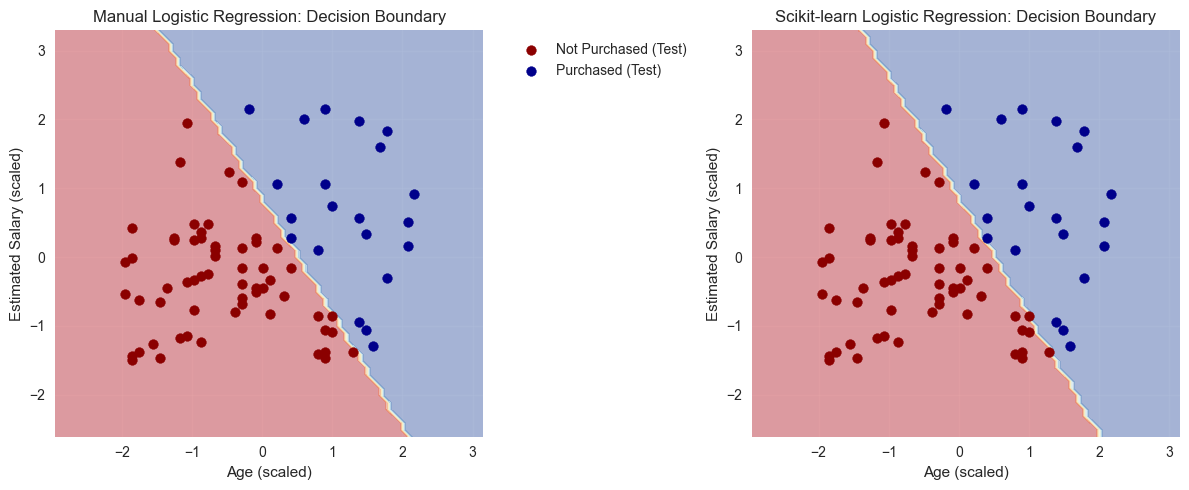

In [111]:
# Step 5: Visualization

# Create mesh grid for decision boundary
x_min, x_max = X_ads_train_scaled_manual[:, 0].min() - 1, X_ads_train_scaled_manual[:, 0].max() + 1
y_min, y_max = X_ads_train_scaled_manual[:, 1].min() - 1, X_ads_train_scaled_manual[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Get predictions for the mesh grid (need to add bias term)
X_mesh = np.c_[np.ones((xx.ravel().shape[0], 1)), xx.ravel(), yy.ravel()]
Z_manual, _ = predict_logistic(X_mesh, beta_final)
Z_manual = Z_manual.reshape(xx.shape)

Z_sklearn_plot = logr_sklearn_manual.predict(np.c_[xx.ravel(), yy.ravel()])
Z_sklearn_plot = Z_sklearn_plot.reshape(xx.shape)

plt.figure(figsize=(12, 5))

# Plot 1: Manual implementation decision boundary
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_manual, alpha=0.4, cmap='RdYlBu')
# plt.scatter(X_ads_train_scaled_manual[y_ads_train == 0][:, 0], X_ads_train_scaled_manual[y_ads_train == 0][:, 1],
#            c='red', label='Not Purchased (Train)', alpha=0.6)
# plt.scatter(X_ads_train_scaled_manual[y_ads_train == 1][:, 0], X_ads_train_scaled_manual[y_ads_train == 1][:, 1],
#            c='blue', label='Purchased (Train)', alpha=0.6)
plt.scatter(X_ads_test_scaled_manual[y_pred_manual == 0][:, 0], X_ads_test_scaled_manual[y_pred_manual == 0][:, 1],
           c='darkred', label='Not Purchased (Test)')
plt.scatter(X_ads_test_scaled_manual[y_pred_manual == 1][:, 0], X_ads_test_scaled_manual[y_pred_manual == 1][:, 1],
           c='darkblue', label='Purchased (Test)')
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title('Manual Logistic Regression: Decision Boundary')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Plot 2: Scikit-learn comparison
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_sklearn_plot, alpha=0.4, cmap='RdYlBu')
# plt.scatter(X_ads_train_scaled_manual[y_ads_train == 0][:, 0], X_ads_train_scaled_manual[y_ads_train == 0][:, 1],
#            c='red', label='Not Purchased (Train)', alpha=0.6)
# plt.scatter(X_ads_train_scaled_manual[y_ads_train == 1][:, 0], X_ads_train_scaled_manual[y_ads_train == 1][:, 1],
#            c='blue', label='Purchased (Train)', alpha=0.6)
plt.scatter(X_ads_test_scaled_manual[y_pred_sklearn_manual == 0][:, 0], X_ads_test_scaled_manual[y_pred_sklearn_manual == 0][:, 1],
           c='darkred', label='Not Purchased (Test)')
plt.scatter(X_ads_test_scaled_manual[y_pred_sklearn_manual == 1][:, 0], X_ads_test_scaled_manual[y_pred_sklearn_manual == 1][:, 1],
           c='darkblue', label='Purchased (Test)')
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title('Scikit-learn Logistic Regression: Decision Boundary')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [112]:
import numpy as np

class OurLogisticRegression:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.cost_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def _compute_cost(self, y, z):
        """Compute logistic regression cost function"""
        m = len(y)
        h = self._sigmoid(z)
        cost = (-1/m) * np.sum(y * np.log(h + 1e-15) + (1 - y) * np.log(1 - h + 1e-15))
        return cost

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            z = X @ self.w + self.b       # Step 3
            y_hat = self._sigmoid(z)      # Step 4

            # Step 6: gradients
            dw = X.T @ (y_hat - y) / n_samples
            db = np.mean(y_hat - y)
            # Step 7: compute cost every 10 iterations
            if _ % 10 == 0:
                cost = self._compute_cost(y, z)
                self.cost_history.append(cost)
                print(f"Iteration {_}: Cost = {cost:.6f}")

            # Step 8: update
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        y_hat = self._sigmoid(X @ self.w + self.b)
        return (y_hat >= 0.5).astype(int)  # Step 8

In [113]:
lor = OurLogisticRegression(lr=0.1, n_iters=100)
lor.fit(X_train_log, y_ads_train)
y_pred_custom_log = lor.predict(X_test_log)
print("Custom Logistic Regression Accuracy:", accuracy_score(y_ads_test, y_pred_custom_log))
print("Sklearn Logistic Regression Accuracy:", accuracy_score(y_ads_test, y_pred_sklearn_manual))

Iteration 0: Cost = 0.693147
Iteration 10: Cost = 0.580764
Iteration 20: Cost = 0.519605
Iteration 30: Cost = 0.482638
Iteration 40: Cost = 0.458325
Iteration 50: Cost = 0.441321
Iteration 60: Cost = 0.428878
Iteration 70: Cost = 0.419455
Iteration 80: Cost = 0.412128
Iteration 90: Cost = 0.406307
Custom Logistic Regression Accuracy: 0.875
Sklearn Logistic Regression Accuracy: 0.8625


## 4. Regularization: L1 and L2

Regularization prevents overfitting by adding a penalty term to the cost function.

### L2 Regularization (Ridge)
**Cost Function:**
$$J(\beta) = \frac{1}{2m} \sum_{i=1}^m (h_\beta(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m} \sum_{j=1}^n \beta_j^2$$

**Gradient:**
$$\frac{\partial}{\partial \beta_j} J(\beta) = \frac{1}{m} \sum_{i=1}^m (h_\beta(x^{(i)}) - y^{(i)}) x_j^{(i)} + \frac{\lambda}{m} \beta_j$$

**Effect:** Shrinks all coefficients towards zero proportionally

### L1 Regularization (Lasso)
**Cost Function:**
$$J(\beta) = \frac{1}{2m} \sum_{i=1}^m (h_\beta(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m} \sum_{j=1}^n |\beta_j|$$

**Gradient:**
$$\frac{\partial}{\partial \beta_j} J(\beta) = \frac{1}{m} \sum_{i=1}^m (h_\beta(x^{(i)}) - y^{(i)}) x_j^{(i)} + \frac{\lambda}{2m} \cdot sign(\beta_j)$$

**Effect:** Can force some coefficients to exactly zero (feature selection)

### Elastic Net
**Combines L1 and L2:**
$$J(\beta) = J_{MSE} + \alpha \cdot (\rho \cdot L1 + (1-\rho) \cdot L2)$$

Where $\alpha$ is regularization strength and $\rho$ controls L1 vs L2 balance.

In [114]:
class RegularizedLinearRegression:
    """
    Linear Regression with L1/L2 regularization implemented from scratch
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000, regularization='l2', lambda_reg=0.1):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.regularization = regularization  # 'l1', 'l2', or 'none'
        self.lambda_reg = lambda_reg
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0

        for iteration in range(self.n_iterations):
            y_pred = self._predict(X)

            # Base cost (MSE)
            cost = (1/(2*m)) * np.sum((y_pred - y)**2)

            # Add regularization term
            if self.regularization == 'l2':
                reg_term = (self.lambda_reg/(2*m)) * np.sum(self.weights**2)
                cost += reg_term
            elif self.regularization == 'l1':
                reg_term = (self.lambda_reg/(2*m)) * np.sum(np.abs(self.weights))
                cost += reg_term

            self.cost_history.append(cost)

            # Compute gradients
            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            # Add regularization to weight gradients
            if self.regularization == 'l2':
                dw += (self.lambda_reg/m) * self.weights
            elif self.regularization == 'l1':
                dw += (self.lambda_reg/(2*m)) * np.sign(self.weights)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            if iteration % 100 == 0:
                print(f"Iteration {iteration}: Cost = {cost:.4f}")

    def _predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def predict(self, X):
        return self._predict(X)


NONE Regularization:
Iteration 0: Cost = 3135614129.3542
Iteration 100: Cost = 50593271.5817
Iteration 200: Cost = 37198797.8484
Iteration 300: Cost = 28647777.9238
Iteration 400: Cost = 23188814.5328
  λ=0: MSE=64019103.1611, Weights: [10499.509]

L2 Regularization:
Iteration 0: Cost = 3135614129.3542
Iteration 100: Cost = 50593271.5817
Iteration 200: Cost = 37198797.8484
Iteration 300: Cost = 28647777.9238
Iteration 400: Cost = 23188814.5328
  λ=0: MSE=64019103.1611, Weights: [10499.509]
Iteration 0: Cost = 3135614129.3542
Iteration 100: Cost = 50620920.6145
Iteration 200: Cost = 37222722.4916
Iteration 300: Cost = 28669475.4882
Iteration 400: Cost = 23209186.4529
  λ=0.01: MSE=64017402.6087, Weights: [10499.098]
Iteration 0: Cost = 3135614129.3542
Iteration 100: Cost = 50869696.7799
Iteration 200: Cost = 37437963.9855
Iteration 300: Cost = 28864667.0904
Iteration 400: Cost = 23392445.3914
  λ=0.1: MSE=64002197.7997, Weights: [10495.4]
Iteration 0: Cost = 3135614129.3542
Iteration 1

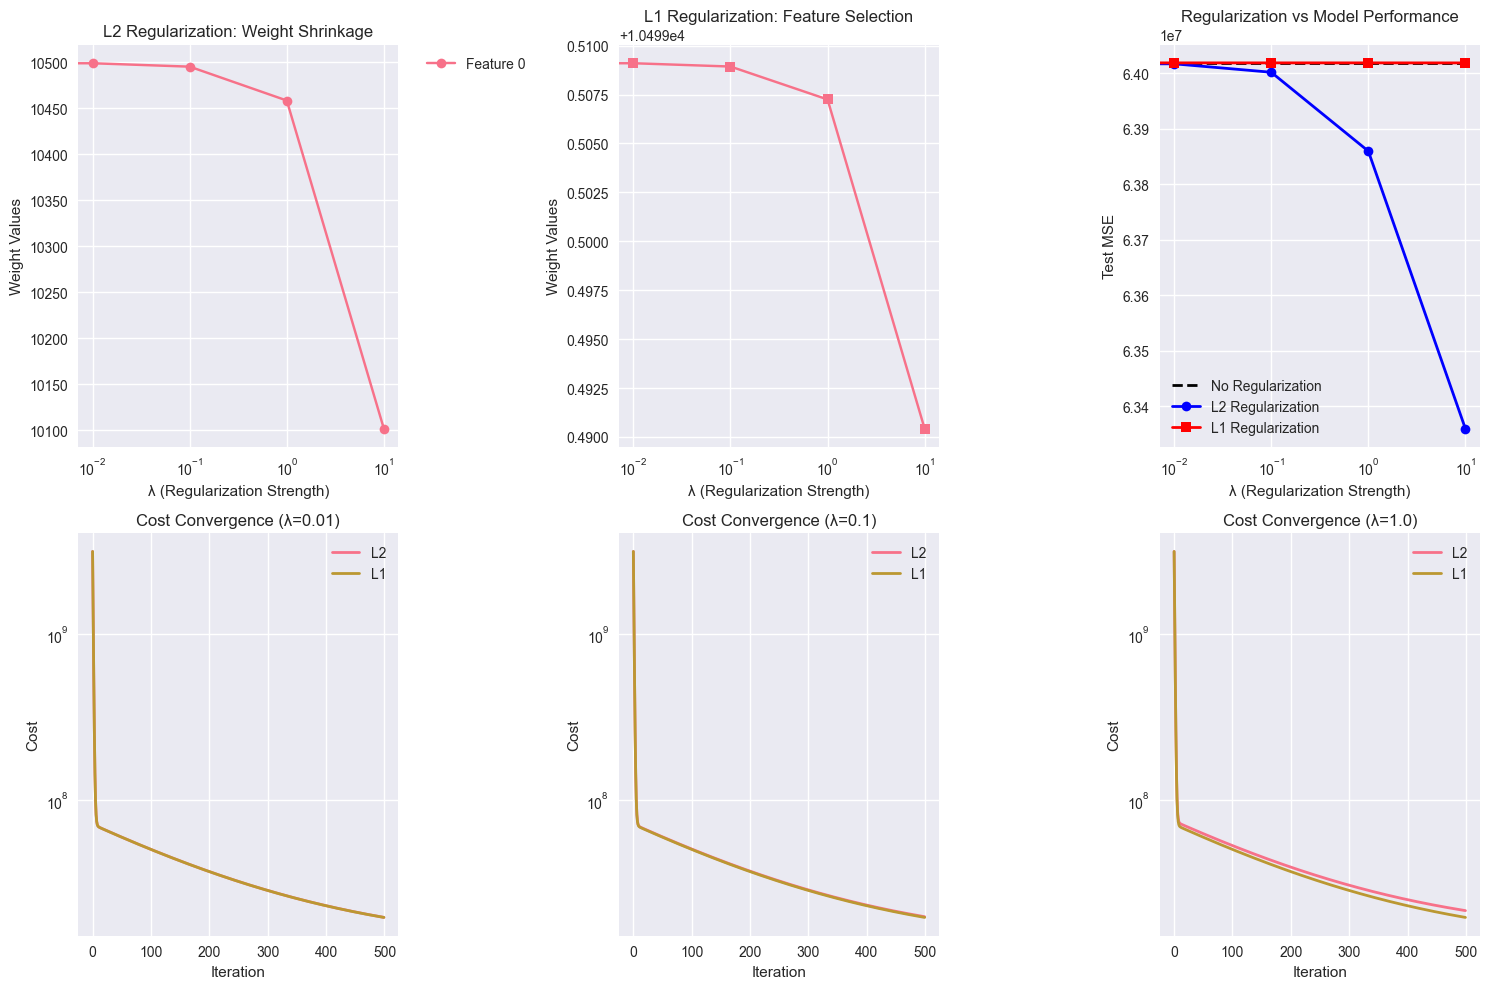

In [115]:
# Test different regularization strengths
lambda_values = [0, 0.01, 0.1, 1.0, 10.0]
regularization_types = ['none', 'l2', 'l1']

results = {}

for reg_type in regularization_types:
    results[reg_type] = {}
    print(f"\n{reg_type.upper()} Regularization:")

    for lambda_reg in lambda_values:
        if reg_type == 'none' and lambda_reg > 0:
            continue

        model = RegularizedLinearRegression(
            learning_rate=0.01, n_iterations=500,
            regularization=reg_type, lambda_reg=lambda_reg
        )
        model.fit(X_salary_train, y_salary_train)
        y_pred = model.predict(X_salary_test)

        mse = mean_squared_error(y_salary_test, y_pred)
        results[reg_type][lambda_reg] = {
            'weights': model.weights.copy(),
            'mse': mse,
            'cost_history': model.cost_history
        }

        print(f"  λ={lambda_reg}: MSE={mse:.4f}, Weights: {model.weights.round(3)}")

# Visualize regularization effects
plt.figure(figsize=(15, 10))

# Plot 1: Weight shrinkage with L2
plt.subplot(2, 3, 1)
lambdas = [0, 0.01, 0.1, 1.0, 10.0]
weights_l2 = [results['l2'][lam]['weights'] for lam in lambdas]
plt.plot(lambdas, weights_l2, marker='o')
plt.xscale('log')
plt.xlabel('λ (Regularization Strength)')
plt.ylabel('Weight Values')
plt.title('L2 Regularization: Weight Shrinkage')
plt.legend([f'Feature {i}' for i in range(10)], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Plot 2: Weight sparsity with L1
plt.subplot(2, 3, 2)
weights_l1 = [results['l1'][lam]['weights'] for lam in lambdas]
plt.plot(lambdas, weights_l1, marker='s')
plt.xscale('log')
plt.xlabel('λ (Regularization Strength)')
plt.ylabel('Weight Values')
plt.title('L1 Regularization: Feature Selection')
plt.grid(True)

# Plot 3: MSE comparison
plt.subplot(2, 3, 3)
mse_none = results['none'][0]['mse']
mse_l2 = [results['l2'][lam]['mse'] for lam in lambdas]
mse_l1 = [results['l1'][lam]['mse'] for lam in lambdas]

plt.plot(lambdas, [mse_none]*len(lambdas), 'k--', label='No Regularization', linewidth=2)
plt.plot(lambdas, mse_l2, 'b-o', label='L2 Regularization', linewidth=2)
plt.plot(lambdas, mse_l1, 'r-s', label='L1 Regularization', linewidth=2)
plt.xscale('log')
plt.xlabel('λ (Regularization Strength)')
plt.ylabel('Test MSE')
plt.title('Regularization vs Model Performance')
plt.legend()
plt.grid(True)

# Plot 4-6: Cost convergence for different λ
for i, lambda_val in enumerate([0.01, 0.1, 1.0]):
    plt.subplot(2, 3, i+4)
    plt.plot(results['l2'][lambda_val]['cost_history'], label='L2', linewidth=2)
    plt.plot(results['l1'][lambda_val]['cost_history'], label='L1', linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.title(f'Cost Convergence (λ={lambda_val})')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')

plt.tight_layout()
plt.show()

## Summary and Key Takeaways

This notebook provided a comprehensive, hands-on exploration of fundamental machine learning concepts:


### Next Steps
1. **Experiment**: Try different learning rates, regularization strengths
2. **Extend**: Add polynomial features, cross-validation
3. **Apply**: Use these concepts on your own datasets
4. **Explore**: Neural networks, advanced optimization (Adam, RMSprop)

### Reflection Questions
- How does changing the learning rate affect convergence?
- When would you choose L1 vs L2 regularization?
- Why is stochastic GD useful for large datasets?
- How can you detect overfitting in your models?

Remember: The best way to learn is by doing! Modify the code, experiment with parameters, and observe how they affect model performance.